# Edge-type consistency analysis across NRI sessions

This notebook loads edge-type probability predictions from multiple NRI training sessions,
computes consistency metrics, and visualizes results. It groups sessions by file prefixes
and, where there is strong consensus on the predicted edge type across sessions, it visualizes
the corresponding edges using `visualization.utils.visualize_graph`.

Data directory (relative to repo root): `data/edge_probabilities/`

Session groups (prefixes):
- `edges_testing_NRI_with_forecast`
- `edges_training_NRI_with_forecast`

Metrics overview (computed per edge across sessions):
- Mean and standard deviation of type probabilities (over sessions).
- Coefficient of variation (CV = std/mean), NaN when mean=0.
- Entropy of the mean distribution per edge; and mean entropy within sessions.
- Agreement fraction of argmax type across sessions; Fleiss' kappa overall.
- Mean pairwise Jensen–Shannon divergence across sessions (per edge) and session×session heatmap.

Visualization of consensus edges: If the agreement fraction for an edge is above a threshold,
the edge is considered to be in consensus and shown with the most agreed-upon type. Type 0 (often "no-edge")
can be skipped when rendering.


In [45]:
import json
import os
from pathlib import Path

import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

from visualization.evaluate_edge_consistency import compute_edge_statistics, load_and_stack
from visualization.utils import visualize_graph, PlottingArgs, get_node_styles

## Configure prefixes, thresholds, and output directories
You can adjust the agreement threshold (default 0.90) and whether to skip the first edge type (typically the "no-edge" class).


In [46]:
data_dir = Path('../data/edge_probabilities')
prefixes = [
    'edges_testing_NRI_with_forecast',
    'edges_training_NRI_with_forecast',
]

# Consensus parameters
agreement_threshold = 0.70  # require >= 90% of sessions to agree on the same argmax type
skip_first_edge_type = True  # often type 0 represents 'no-edge'
latent_edge_weight = 2.0  # scales probabilities for rendering; weight>=1 is drawn in the utility

# Output base directory for figures and CSVs generated by analysis code
out_base = Path('output/edge_consistency_notebook')
os.makedirs(out_base, exist_ok=True)

## Run analysis for each session group
For each prefix, we load all matching .npy files, stack them into shape (S, E, K), and compute summary metrics.
We also generate and display a few diagnostic plots.


In [47]:
edge_statistics = {}
for prefix in prefixes:
    print(f'=== Analyzing prefix: {prefix} ===')
    # Load and analyze
    stacked, files = load_and_stack(data_dir, prefix)
    stats = compute_edge_statistics(stacked)
    edge_statistics[prefix] = stats
    # Show basic summary
    S, E, K = stacked.shape
    summary = {
        'n_sessions': int(S),
        'n_edges': int(E),
        'n_types': int(K),
        'kappa_overall': float(stats['kappa_overall']) if stats['kappa_overall'] is not None else None,
        'mean_js_over_edges': float(np.nanmean(stats['js_per_edge'])),
        'median_js_over_edges': float(np.nanmedian(stats['js_per_edge'])),
    }
    print("Summary: " + json.dumps(summary, indent=2))

print('Analysis complete.')

=== Analyzing prefix: edges_testing_NRI_with_forecast ===
Summary: {
  "n_sessions": 10,
  "n_edges": 3192,
  "n_types": 2,
  "kappa_overall": 0.4707511508000692,
  "mean_js_over_edges": 0.14356736028692363,
  "median_js_over_edges": 0.10903285136015081
}
=== Analyzing prefix: edges_training_NRI_with_forecast ===
Summary: {
  "n_sessions": 10,
  "n_edges": 3192,
  "n_types": 2,
  "kappa_overall": 0.46846192070253995,
  "mean_js_over_edges": 0.14402131313850416,
  "median_js_over_edges": 0.10924278395943073
}
Analysis complete.


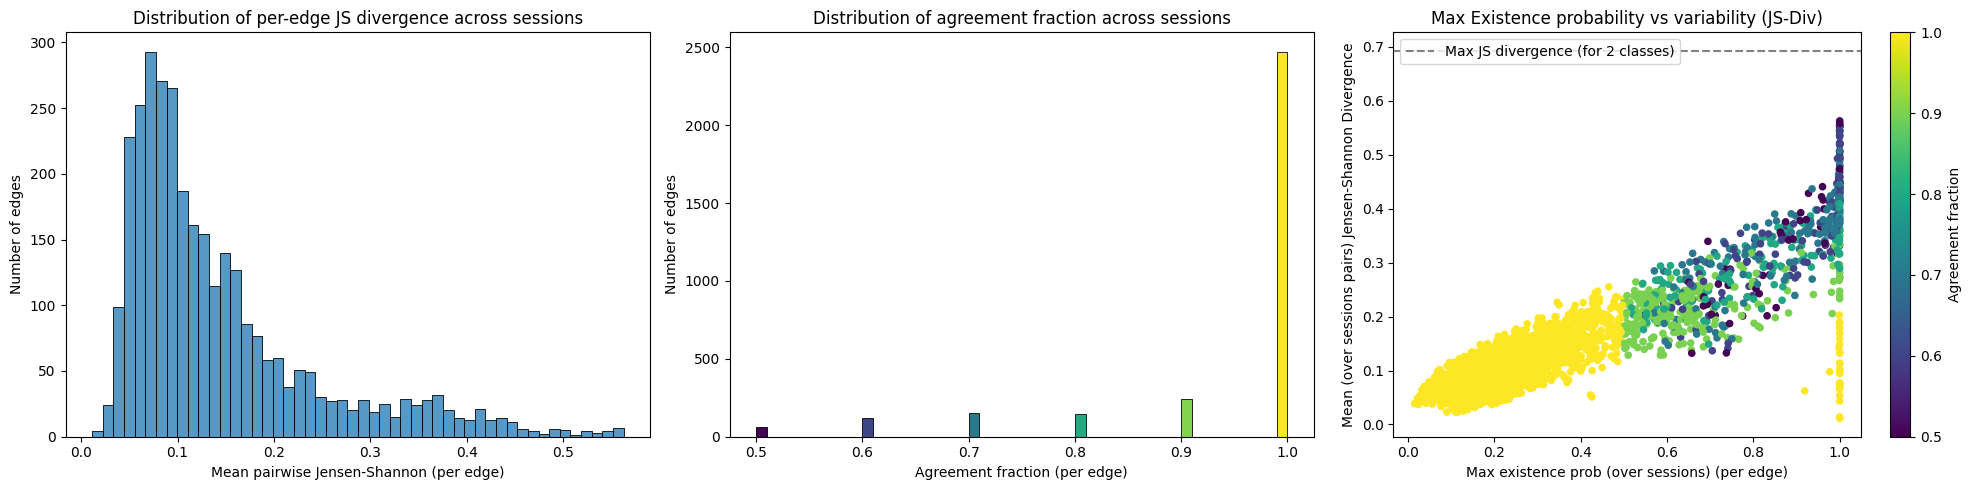

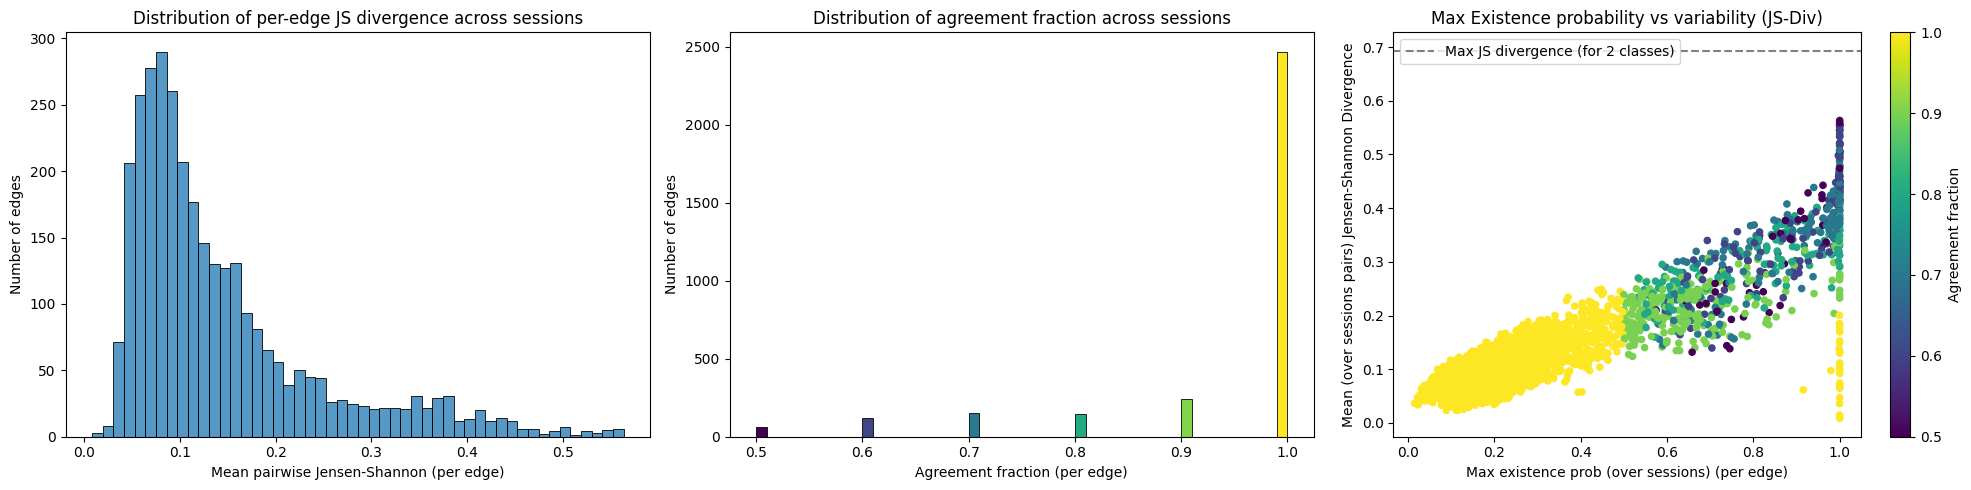

In [48]:
from matplotlib.colors import Normalize

for prefix in prefixes:
    stats = edge_statistics[prefix]
    out_dir = Path(os.path.join(out_base, prefix))
    os.makedirs(out_dir, exist_ok=True)
    # draw
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    # 1. mean pairwise js div
    sns.histplot(stats['js_per_edge'], bins=50, ax=axes[0])
    axes[0].set_xlabel('Mean pairwise Jensen-Shannon (per edge)')
    axes[0].set_ylabel('Number of edges')
    axes[0].set_title('Distribution of per-edge JS divergence across sessions')
    # 2. agreement fraction
    cmap = plt.cm.viridis
    norm = Normalize(vmin=stats['agreement_fraction'].min(), vmax=stats['agreement_fraction'].max())
    colors = cmap(norm(stats['agreement_fraction']))

    sns.histplot(
        stats['agreement_fraction'],
        bins=50,
        ax=axes[1],
        color=None,
        kde=False,
        element="bars"
    )
    for patch, val in zip(axes[1].patches, np.linspace(stats['agreement_fraction'].min(), stats['agreement_fraction'].max(), len(axes[1].patches))):
        patch.set_facecolor(cmap(norm(val)))

    axes[1].set_xlabel('Agreement fraction (per edge)')
    axes[1].set_ylabel('Number of edges')
    axes[1].set_title('Distribution of agreement fraction across sessions')
    # 3. Max Existence probability vs variability (JS-Div)
    sc = axes[2].scatter(stats['max_exists_probs'], stats['js_per_edge'], c=stats['agreement_fraction'], cmap="viridis", s=20)
    axes[2].set_xlabel('Max existence prob (over sessions) (per edge)')
    axes[2].set_ylabel('Mean (over sessions pairs) Jensen-Shannon Divergence')
    axes[2].set_title('Max Existence probability vs variability (JS-Div)')
    axes[2].axhline(0.6931, color='gray', linestyle='--', label='Max JS divergence (for 2 classes)')
    axes[2].legend(loc="upper left")
    cbar = plt.colorbar(sc, ax=axes[2], label='Agreement fraction')
    fig.tight_layout()

    fig.savefig(Path(out_dir, "consensus_summary.png"))
    plt.show()

## Metric explanations
- **Mean probabilities (per edge, per type):** Average of the predicted type probabilities across sessions.
- **Standard deviation (per edge, per type):** Spread of predicted probabilities across sessions.
- **Coefficient of variation (CV):** std/mean; larger values suggest higher relative variability.
- **Entropy of mean distribution:** Entropy (base 2) of the mean type distribution per edge; higher means less certainty.
- **Mean within-session entropy:** Average entropy across sessions for each edge; captures noisiness per session.
- **Agreement fraction:** Fraction of sessions that selected the same argmax type for an edge (1.0 means full agreement).
- **Fleiss' kappa (overall):** Agreement beyond chance over all edges and sessions; 0≈chance, >0 better than chance.
- **Per-edge JS divergence:** Mean pairwise Jensen–Shannon divergence across sessions for each edge; higher means less consistent.


## Visualize edges with strong consensus
We mark an edge as "consensus" when its agreement fraction ≥ the threshold above.
For visualization, we build a latent edge-probabilities array of shape (E, K): for consensus edges,
we keep the mean probability on the consensus type and set others to zero; for non-consensus edges, we set all zeros.

Rendering uses `visualization.utils.visualize_graph`. If the number of edges E matches a fully-connected directed graph
on N nodes (E = N·(N−1)), we infer N and render a graph using a circular fallback layout (unless you provide node styles).
Note: If repository dependencies like `grid2op` are not installed, graph rendering might be skipped—install requirements
to enable full visualization.


edges_testing_NRI_with_forecast - Edges: 3192, Types: 2, Nodes: 57
Consensus edges above threshold: 147


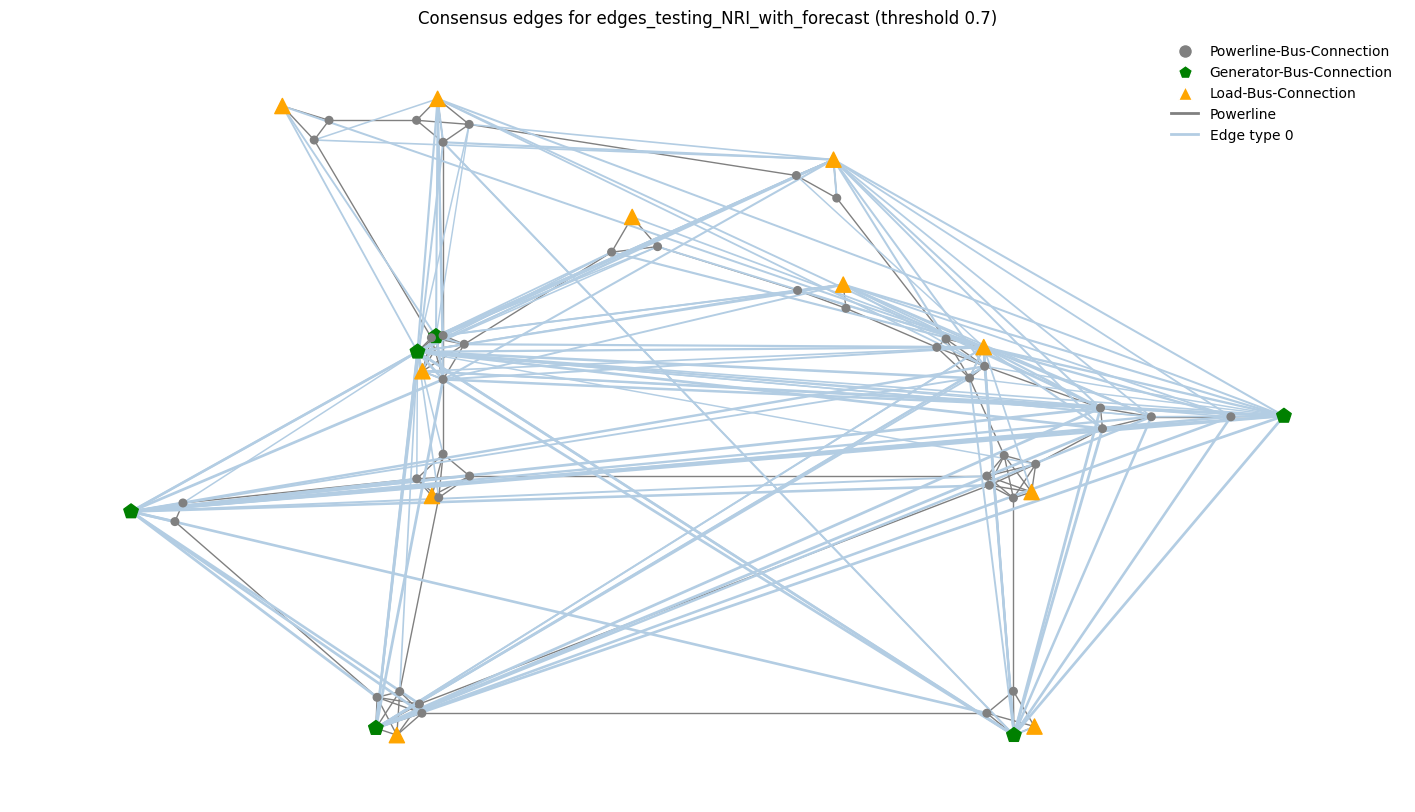

Saved consensus graph to `output/edge_consistency_notebook/edges_testing_NRI_with_forecast/consensus_graph.png`
edges_training_NRI_with_forecast - Edges: 3192, Types: 2, Nodes: 57
Consensus edges above threshold: 146


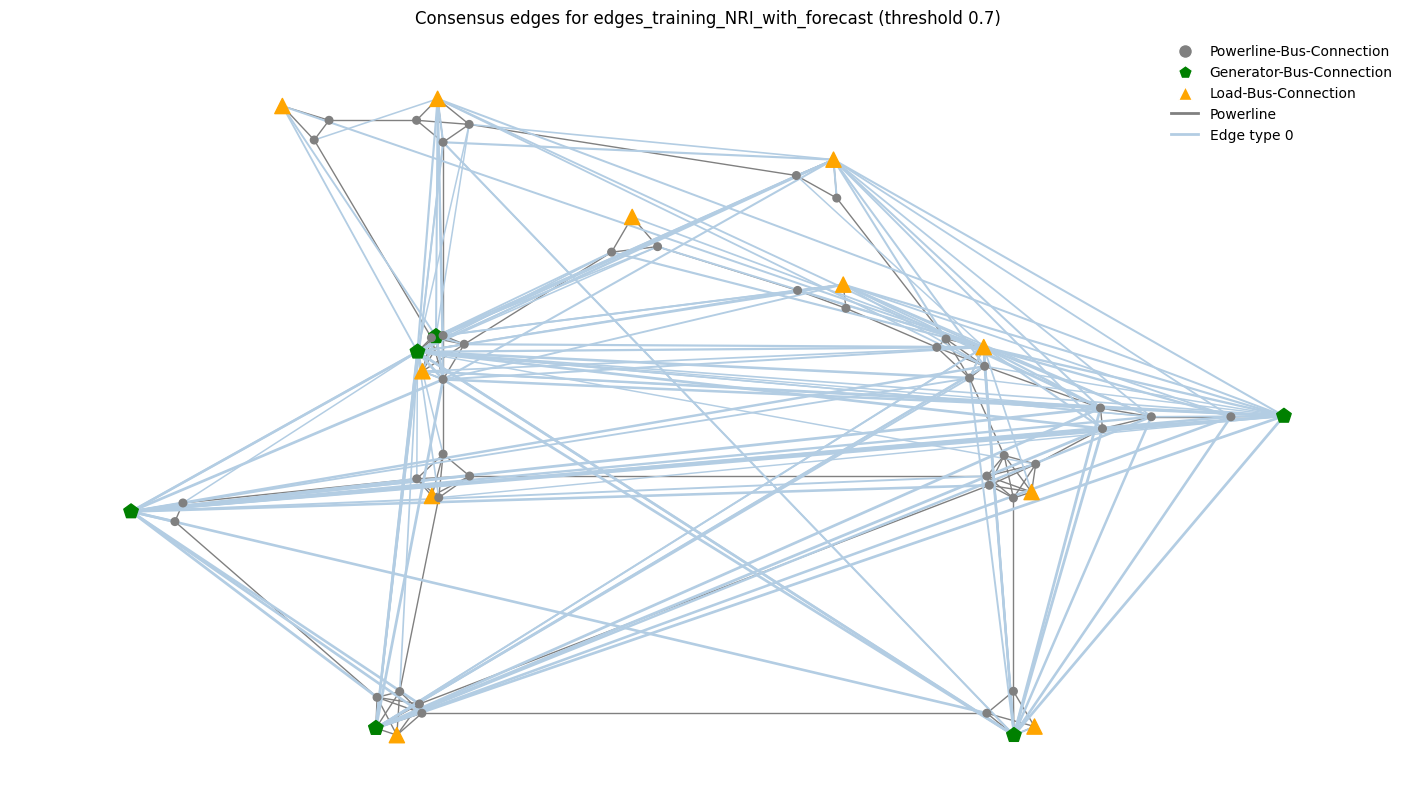

Saved consensus graph to `output/edge_consistency_notebook/edges_training_NRI_with_forecast/consensus_graph.png`


In [49]:
import grid2op
from common import BusConnectivityGraphObsSpace, EDGE_INDEX


def infer_num_nodes_from_E(E: int) -> int | None:
    """Infer number of nodes N from number of directed edges E in a fully connected graph (no self-loops): E = N*(N-1).
    Returns N if integer solution exists, else None.
    """
    disc = 1 + 4 * E
    sqrt_disc = int(np.sqrt(disc))
    if sqrt_disc * sqrt_disc != disc:
        return None
    N_num = 1 + sqrt_disc
    if N_num % 2 != 0:
        return None
    N = N_num // 2
    return int(N) if N * (N - 1) == E else None


def build_consensus_latent_probs(stats: dict, threshold: float, skip_first_type: bool = True) -> np.ndarray:
    """Build (E, K) array with nonzero probabilities only for edges surpassing the agreement threshold.
    Keeps the mean probability for the consensus (mode) type; zero elsewhere.
    Optionally ignore edges whose consensus type is 0 (often 'no-edge').
    """
    mean_probs = stats['mean_probs']  # (E, K)
    argmax_mode = stats['argmax_mode']  # (E,)
    agreement_fraction = stats['agreement_fraction']  # (E,)
    out = np.zeros_like(mean_probs)
    mask = agreement_fraction >= threshold
    for e in np.where(mask)[0]:
        t = int(argmax_mode[e])
        if skip_first_type and t == 0:
            continue
        out[e, t] = float(mean_probs[e, t])
    return out


# Generate and display consensus graphs per prefix; also save PNGs next to other outputs
for prefix in prefixes:
    stacked, files = load_and_stack(data_dir, prefix)
    S, E, K = stacked.shape
    N = infer_num_nodes_from_E(E)
    consensus_latent = build_consensus_latent_probs(edge_statistics[prefix], agreement_threshold, skip_first_edge_type)
    n_consensus_edges = int((consensus_latent.sum(axis=1) > 0).sum())
    print(f"{prefix} - Edges: {E}, Types: {K}, Nodes: {N if N is not None else "(not a fully-connected directed E)"}\n"
          f"Consensus edges above threshold: {n_consensus_edges}")

    if N is None:
        print('Cannot infer number of nodes from E; expected E = N·(N−1). Skipping graph visualization.')
        continue
    # Safety check to satisfy visualize_graph assertion
    assert consensus_latent.shape == (E, K)
    assert N * (N - 1) == E, 'E must equal N*(N-1) for visualize_graph'
    env = grid2op.make("l2rpn_case14_sandbox")
    edge_index = BusConnectivityGraphObsSpace(grid2op_observation_space=env.observation_space).to_gym(env.reset())[EDGE_INDEX]
    args = PlottingArgs(
        num_nodes=N,
        node_styles=get_node_styles(env=env, observation_space=BusConnectivityGraphObsSpace),
        powerline_edge_index=edge_index,
        latent_edge_probs=consensus_latent,
        latent_edge_weight=latent_edge_weight,
        do_weight_sweep=False,
        skip_first_edge_type=skip_first_edge_type,
    )
    fig = visualize_graph(args)
    plt.title(f'Consensus edges for {prefix} (threshold {agreement_threshold})')
    plt.show()
    # Save the consensus graph
    save_path = Path(os.path.join(out_base, prefix, 'consensus_graph.png'))
    try:
        fig.savefig(save_path, bbox_inches='tight')
        print(f'Saved consensus graph to `{save_path}`')
    except Exception as ex:
        print('Could not save consensus graph:', ex)
